In [33]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_community.chat_models import ChatOllama


In [34]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb: float
    boundary_percent:float
    summary:str

In [35]:
def calculate_sr(state:BatsmanState)->BatsmanState:
    sr = (state['runs']/state['balls'])*100
    return {'sr':sr}

In [36]:
def calculate_bpb(state:BatsmanState)->BatsmanState:
    bpb=state['balls']/(state['fours']+state['sixes'])
    return {'bpb':bpb}

In [37]:
def calculate_boundary_percent(state:BatsmanState)->BatsmanState:
    boundary_percent=(((state['fours']*4) + (state['sixes']*6)) /state['runs'])*100
    return {'boundary_percent':boundary_percent}

In [43]:
def summary(state:BatsmanState)->BatsmanState:
    summary_text =f"""
    Strike Rate = {state['sr']} \n
    Balls per boundary = {state['bpb']} \n
    Boundary percent = {state['boundary_percent']} \n
    """
    return {'summary':summary_text}

In [44]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_boundary_percent' ,calculate_boundary_percent)
graph.add_node('calculate_sr' ,calculate_sr)
graph.add_node('calculate_bpb' ,calculate_bpb)
graph.add_node('summary' ,summary)

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_percent','summary')

graph.add_edge('summary',END)

In [45]:
workflow = graph.compile()

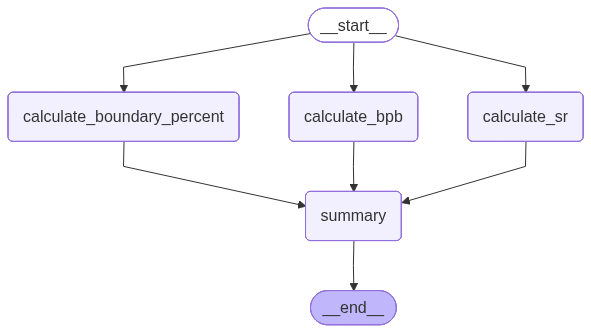

In [46]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [47]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n    Strike Rate = 200.0 \n\n    Balls per boundary = 5.0 \n\n    Boundary percent = 48.0 \n\n    '}